In [18]:
import xarray as xr
import numpy as np

# The known-good reference file
ref = xr.open_dataset("/glade/campaign/cesm/development/liwg/forAdvik/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc", decode_cf=False)

# Regridded atmospheric files
lgm_temp   = xr.open_dataset("lgm21ka_atm_TREFHT_on_cism8km.nc", decode_cf=False)
lig_temp   = xr.open_dataset("lig127ka_atm_TREFHT_on_cism8km.nc", decode_cf=False)
lgm_precip = xr.open_dataset("lgm21ka_atm_PRECIP_on_cism8km.nc", decode_cf=False)
lig_precip = xr.open_dataset("lig127ka_atm_PRECIP_on_cism8km.nc", decode_cf=False)

# Regridded ocean thermal forcing files
lgm_tf = xr.open_dataset("lgm21ka_ocn_thermal_forcing_on_cism8km.nc", decode_cf=False)
lig_tf = xr.open_dataset("lig127ka_ocn_thermal_forcing_on_cism8km.nc", decode_cf=False)

# Take annual means (12 months -> 1 timestep)
lgm_temp_ann   = lgm_temp.mean(dim="time")
lig_temp_ann   = lig_temp.mean(dim="time")
lgm_precip_ann = lgm_precip.mean(dim="time")
lig_precip_ann = lig_precip.mean(dim="time")
lgm_tf_ann     = lgm_tf.mean(dim="time")
lig_tf_ann     = lig_tf.mean(dim="time")

# Restore time dimension as single slice to match reference (time: 1)
lgm_temp_ann   = lgm_temp_ann.expand_dims({"time": [0.0]})
lig_temp_ann   = lig_temp_ann.expand_dims({"time": [0.0]})
lgm_precip_ann = lgm_precip_ann.expand_dims({"time": [0.0]})
lig_precip_ann = lig_precip_ann.expand_dims({"time": [0.0]})
lgm_tf_ann     = lgm_tf_ann.expand_dims({"time": [0.0]})
lig_tf_ann     = lig_tf_ann.expand_dims({"time": [0.0]})

print("=== REFERENCE ===")
print(ref)
print("\n=== LGM TEMP (annual mean) ===")
print(lgm_temp_ann)
print("\n=== LGM TF (annual mean) ===")
print(lgm_tf_ann)

=== REFERENCE ===
<xarray.Dataset> Size: 118MB
Dimensions:          (time: 1, x1: 761, y1: 761, x0: 760, y0: 760, zocn: 30)
Coordinates:
  * time             (time) float32 4B 0.0
  * x1               (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * y1               (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * x0               (x0) float32 3kB -3.036e+06 -3.028e+06 ... 3.036e+06
  * y0               (y0) float32 3kB -3.036e+06 -3.028e+06 ... 3.036e+06
  * zocn             (zocn) float32 120B -30.0 -90.0 ... -1.71e+03 -1.77e+03
Data variables: (12/22)
    firn             (time, y1, x1) float32 2MB ...
    geoid            (time, y1, x1) float32 2MB ...
    mask             (time, y1, x1) float32 2MB ...
    thk              (time, y1, x1) float32 2MB ...
    topg             (time, y1, x1) float32 2MB ...
    topg_err         (time, y1, x1) float32 2MB ...
    ...               ...
    dthk_dt_obs      (time, y1, x1) float32 2MB ...
    Lat1             (time, y1, x1) f

In [19]:
# Pull coordinate arrays from reference
x1_vals = ref["x1"].values
y1_vals = ref["y1"].values

# Fix thermal forcing - redo annual mean with fill value masking
lgm_tf_masked = lgm_tf.where(lgm_tf != -99999)
lig_tf_masked = lig_tf.where(lig_tf != -99999)

lgm_tf_ann = lgm_tf_masked.mean(dim="time").expand_dims({"time": [0.0]})
lig_tf_ann = lig_tf_masked.mean(dim="time").expand_dims({"time": [0.0]})

# Restore -99999 fill where all months were invalid
lgm_tf_ann["thermal_forcing"] = lgm_tf_ann["thermal_forcing"].fillna(-99999)
lig_tf_ann["thermal_forcing"] = lig_tf_ann["thermal_forcing"].fillna(-99999)

def format_dataset(ds, var_old, var_new, x1_vals, y1_vals, units_convert=None):
    # Rename variable
    ds = ds.rename({var_old: var_new})
    
    # Convert units if needed
    if units_convert == "K_to_C":
        ds[var_new] = ds[var_new] - 273.15
        ds[var_new].attrs["units"] = "degree celsius"
    
    # Assign x1, y1 as proper coordinates
    ds = ds.assign_coords(
        x1=("x1", x1_vals.astype("float32")),
        y1=("y1", y1_vals.astype("float32"))
    )
    
    # Fix time to float32
    ds["time"] = ds["time"].astype("float32")
    
    return ds

lgm_temp_final   = format_dataset(lgm_temp_ann,   "TREFHT", "artm", x1_vals, y1_vals, units_convert="K_to_C")
lig_temp_final   = format_dataset(lig_temp_ann,   "TREFHT", "artm", x1_vals, y1_vals, units_convert="K_to_C")
lgm_precip_final = format_dataset(lgm_precip_ann, "PRECIP", "smb",  x1_vals, y1_vals)
lig_precip_final = format_dataset(lig_precip_ann, "PRECIP", "smb",  x1_vals, y1_vals)

# For TF, drop lat/lon data variables and assign x1/y1 coords
lgm_tf_final = lgm_tf_ann.drop_vars(["lat", "lon"])\
    .assign_coords(
        x1=("x1", x1_vals.astype("float32")),
        y1=("y1", y1_vals.astype("float32"))
    )
lig_tf_final = lig_tf_ann.drop_vars(["lat", "lon"])\
    .assign_coords(
        x1=("x1", x1_vals.astype("float32")),
        y1=("y1", y1_vals.astype("float32"))
    )
lgm_tf_final["time"] = lgm_tf_final["time"].astype("float32")
lig_tf_final["time"] = lig_tf_final["time"].astype("float32")

print(lgm_temp_final)
print(lgm_precip_final)
print(lgm_tf_final)

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1, y1: 761, x1: 761)
Coordinates:
  * time     (time) float32 4B 0.0
  * x1       (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y1       (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
Data variables:
    artm     (time, y1, x1) float32 2MB 1.168 1.134 1.1 ... -3.675 -3.607 -3.538
<xarray.Dataset> Size: 7MB
Dimensions:  (time: 1, y1: 761, x1: 761)
Coordinates:
  * time     (time) float32 4B 0.0
  * x1       (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y1       (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
Data variables:
    smb      (time, y1, x1) float32 2MB 2.794e-08 2.795e-08 ... 2.961e-08
    lat      (time, y1, x1) float32 2MB -51.85 -51.9 -51.94 ... -51.9 -51.85
    lon      (time, y1, x1) float32 2MB 225.0 224.9 224.8 ... 44.85 44.92 45.0
<xarray.Dataset> Size: 70MB
Dimensions:          (time: 1, zocn: 30, y1: 761, x1: 761)
Coordinates:
  * time             (time) f

In [20]:
# Drop lat/lon from precip and convert units: m/s -> mm/yr water equivalent
# 1 m/s * 86400 s/day * 365 days/yr * 1000 mm/m = 3.1536e10 mm/yr
ms_to_mmyr = 86400 * 365 * 1000

lgm_precip_final = lgm_precip_final.drop_vars(["lat", "lon"])
lig_precip_final = lig_precip_final.drop_vars(["lat", "lon"])

lgm_precip_final["smb"] = lgm_precip_final["smb"] * ms_to_mmyr
lig_precip_final["smb"] = lig_precip_final["smb"] * ms_to_mmyr

lgm_precip_final["smb"].attrs["units"] = "mm/yr water equivalent"
lig_precip_final["smb"].attrs["units"] = "mm/yr water equivalent"

print(lgm_precip_final)
print("smb range:", float(lgm_precip_final["smb"].min()), "to", float(lgm_precip_final["smb"].max()))

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1, y1: 761, x1: 761)
Coordinates:
  * time     (time) float32 4B 0.0
  * x1       (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y1       (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
Data variables:
    smb      (time, y1, x1) float32 2MB 881.2 881.4 881.6 ... 929.5 931.7 933.8
smb range: 3.660698652267456 to 954.00390625


In [21]:
def assemble_forcing(temp_ds, precip_ds, tf_ds, ref, label):
    # Merge all three datasets
    ds = xr.merge([temp_ds, precip_ds, tf_ds])
    
    # Copy projection attributes from reference
    for attr in ref.attrs:
        ds.attrs[attr] = ref.attrs[attr]
    
    # Override author
    ds.attrs["author"] = "Advik Iyer-Swaran"
    ds.attrs["description"] = f"Paleo climate forcing for CISM, {label}"
    
    return ds

lgm_forcing = assemble_forcing(lgm_temp_final, lgm_precip_final, lgm_tf_final, ref, "LGM 21ka")
lig_forcing = assemble_forcing(lig_temp_final, lig_precip_final, lig_tf_final, ref, "LIG 127ka")

print(lgm_forcing)
print(lig_forcing)

<xarray.Dataset> Size: 74MB
Dimensions:          (time: 1, y1: 761, x1: 761, zocn: 30)
Coordinates:
  * time             (time) float32 4B 0.0
  * x1               (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * y1               (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * zocn             (zocn) float32 120B -30.0 -90.0 ... -1.71e+03 -1.77e+03
Data variables:
    artm             (time, y1, x1) float32 2MB 1.168 1.134 ... -3.607 -3.538
    smb              (time, y1, x1) float32 2MB 881.2 881.4 ... 931.7 933.8
    thermal_forcing  (time, zocn, y1, x1) float32 69MB 4.086 4.065 ... -0.3054
Attributes: (12/14)
    author:                                 Advik Iyer-Swaran
    proj4:                                  +init=epsg:3031
    latitude_of_projection_origin:          -90.
    standard_parallel:                      -71.
    straight_vertical_longitude_from_pole:  0.
    semi_major_axis:                        6378273.
    ...                                     ...

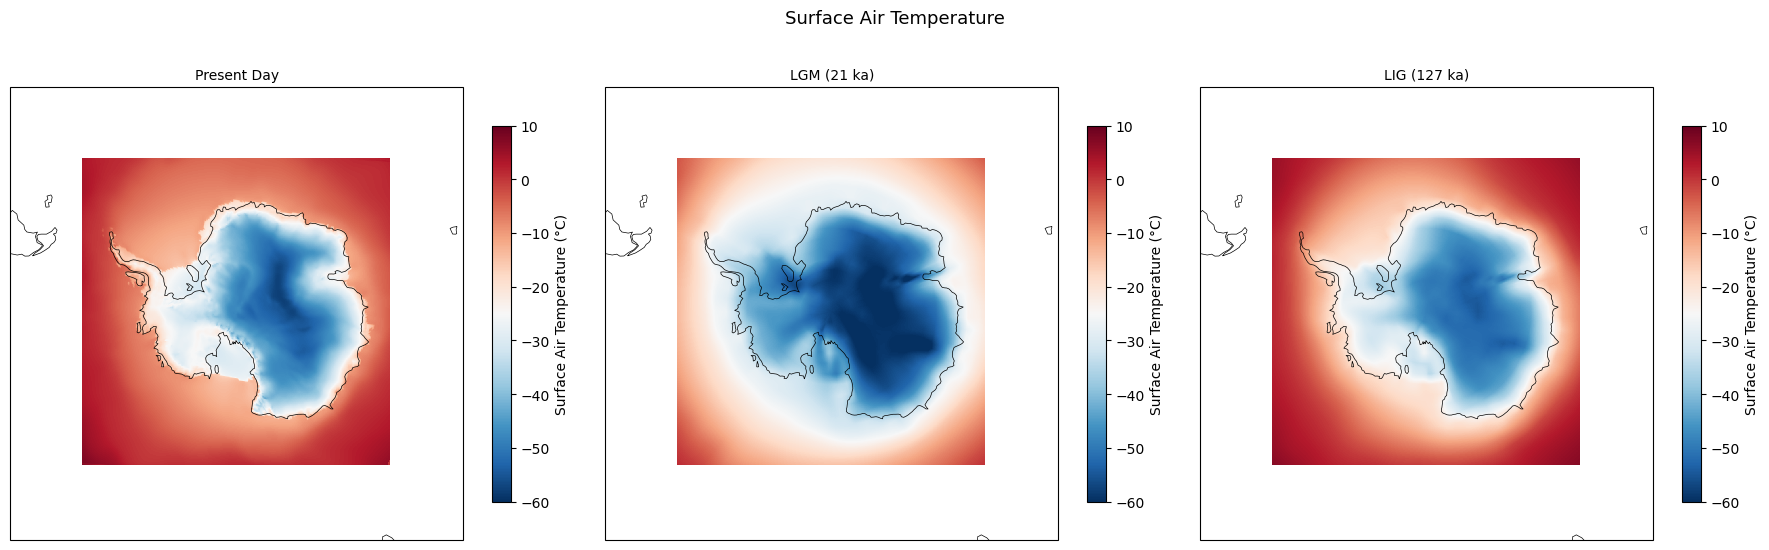

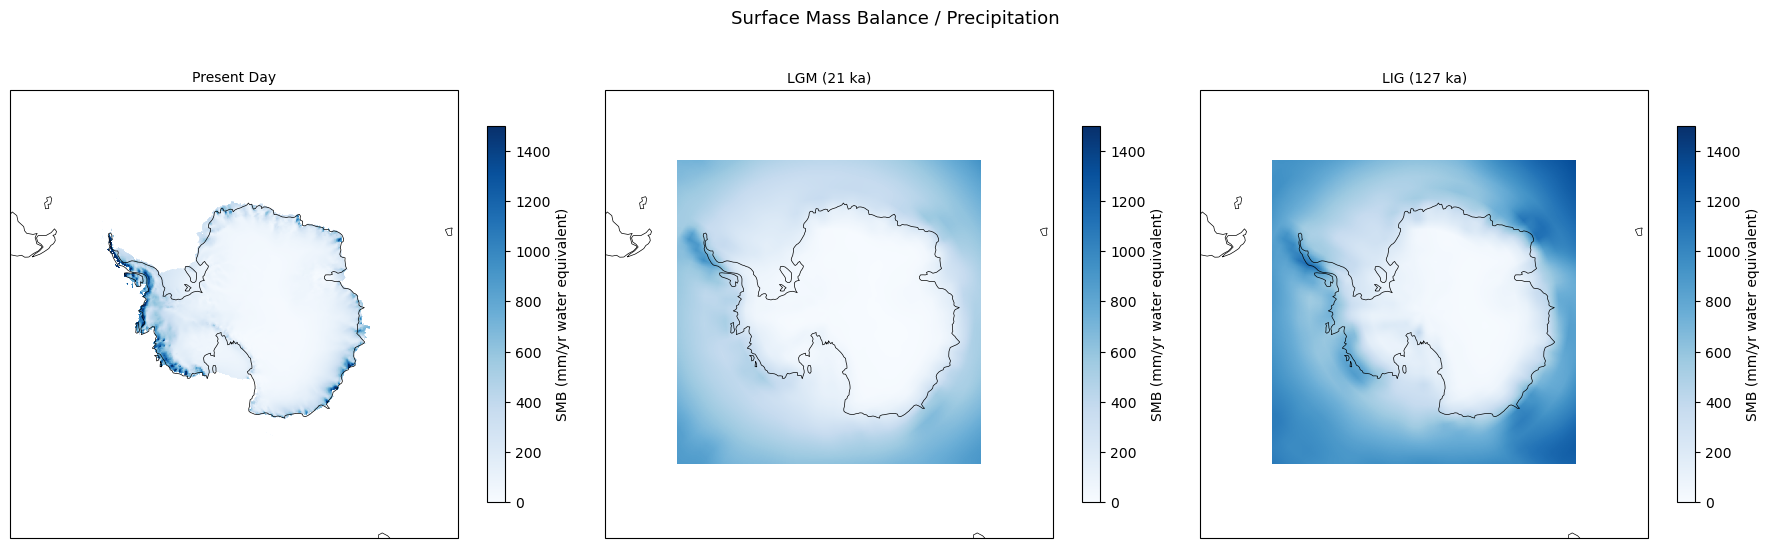

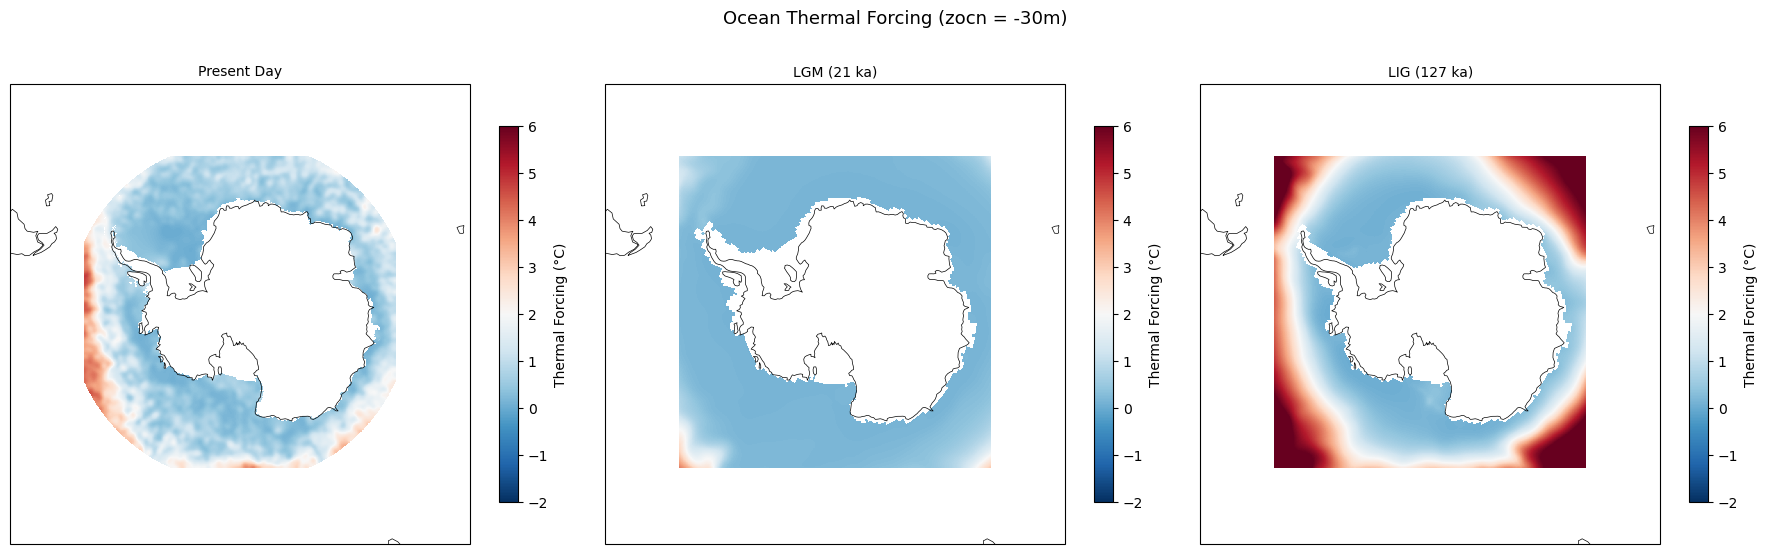

In [24]:
# ── 1. Surface Air Temperature (artm) ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

ref_artm = ref["artm"].isel(time=0).values
ref_artm = np.where(ref_artm == -99999, np.nan, ref_artm)

for ax, data, title in zip(axes,
                            [ref_artm,
                             lgm_forcing["artm"].isel(time=0).values,
                             lig_forcing["artm"].isel(time=0).values],
                            ["Present Day", "LGM (21 ka)", "LIG (127 ka)"]):
    p = polar_pcolormesh(ax, lon2d, lat2d, data, "RdBu_r", -60, 10, title)
    plt.colorbar(p, ax=ax, label="Surface Air Temperature (°C)", shrink=0.7)

plt.suptitle("Surface Air Temperature", fontsize=13)
plt.tight_layout()
#plt.savefig("comparison_artm.png", dpi=150)
plt.show()

# ── 2. SMB ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

ref_smb = ref["smb"].isel(time=0).values
ref_smb = np.where(np.abs(ref_smb) > 1e6, np.nan, ref_smb)

for ax, data, title in zip(axes,
                            [ref_smb,
                             lgm_forcing["smb"].isel(time=0).values,
                             lig_forcing["smb"].isel(time=0).values],
                            ["Present Day", "LGM (21 ka)", "LIG (127 ka)"]):
    p = polar_pcolormesh(ax, lon2d, lat2d, data, "Blues", 0, 1500, title)
    plt.colorbar(p, ax=ax, label="SMB (mm/yr water equivalent)", shrink=0.7)

plt.suptitle("Surface Mass Balance / Precipitation", fontsize=13)
plt.tight_layout()
#plt.savefig("comparison_smb.png", dpi=150)
plt.show()

# ── 3. Thermal Forcing ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

ice_mask = ref["mask"].isel(time=0).values
ref_tf = np.where((ref_tf == -99999) | (ice_mask > 0), np.nan, ref_tf)
lgm_tf_plot = np.where(lgm_forcing["thermal_forcing"].isel(time=0, zocn=0).values == -99999, np.nan,
                        lgm_forcing["thermal_forcing"].isel(time=0, zocn=0).values)
lig_tf_plot = np.where(lig_forcing["thermal_forcing"].isel(time=0, zocn=0).values == -99999, np.nan,
                        lig_forcing["thermal_forcing"].isel(time=0, zocn=0).values)

for ax, data, title in zip(axes,
                            [ref_tf, lgm_tf_plot, lig_tf_plot],
                            ["Present Day", "LGM (21 ka)", "LIG (127 ka)"]):
    p = polar_pcolormesh(ax, lon2d, lat2d, data, "RdBu_r", -2, 6, title)
    plt.colorbar(p, ax=ax, label="Thermal Forcing (°C)", shrink=0.7)

plt.suptitle("Ocean Thermal Forcing (zocn = -30m)", fontsize=13)
plt.tight_layout()
#plt.savefig("comparison_thermal_forcing.png", dpi=150)
plt.show()

In [29]:
ipi_path = "/glade/campaign/cesm/community/palwg/iCESM1.2-DeglacialSlice/b.e12.B1850C5.f19_g16.iPI.01/climo/b.e12.B1850C5.f19_g16.iPI.01.cam.h0.0801-0900.climo.nc"

ipi_ds = xr.open_dataset(ipi_path, chunks={"time": 12})

# Crop to Antarctica (same lat range as LGM/LIG files: -90 to -50)
ipi_ds = ipi_ds.sel(lat=slice(-90, -50))

# Compute PRECIP = PRECC + PRECL
ipi_ds["PRECIP"] = ipi_ds["PRECC"] + ipi_ds["PRECL"]

print(ipi_ds["TREFHT"])
print(ipi_ds["PRECIP"])
print("lat range:", ipi_ds["lat"].values[[0, -1]])

<xarray.DataArray 'TREFHT' (time: 12, lat: 22, lon: 144)> Size: 152kB
dask.array<getitem, shape=(12, 22, 144), dtype=float32, chunksize=(12, 22, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float64 176B -90.0 -88.11 -86.21 ... -54.0 -52.11 -50.21
  * time     (time) object 96B 0850-08-02 12:00:00 ... 0851-07-02 12:00:00
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean
<xarray.DataArray 'PRECIP' (time: 12, lat: 22, lon: 144)> Size: 152kB
dask.array<add, shape=(12, 22, 144), dtype=float32, chunksize=(12, 22, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float64 176B -90.0 -88.11 -86.21 ... -54.0 -52.11 -50.21
  * time     (time) object 96B 0850-08-02 12:00:00 ... 0851-07-02 12:00:00
lat range: [-90.         -50.21052632]


In [35]:
import xesmf as xe
import xarray as xr
import numpy as np

# Reload all datasets
cism_grid_ds = xr.open_dataset("/glade/u/home/ifairuz/processed_paleo_data/CISM3_initialization_AIS_08000.LatLon.nc")
ref = xr.open_dataset("/glade/campaign/cesm/development/liwg/forAdvik/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc", decode_cf=False)

# Coordinate arrays
x1_vals = ref["x1"].values
y1_vals = ref["y1"].values
lon2d = ref["Lon1"].isel(time=0).values
lat2d = ref["Lat1"].isel(time=0).values
ms_to_mmyr = 86400 * 365 * 1000

# CISM target grid
grid_thick = xr.Dataset(
    {
        "lat": (("y1", "x1"), cism_grid_ds["Lat1"].data),
        "lon": (("y1", "x1"), cism_grid_ds["Lon1"].data)
    }
)

# Regrid iPI to CISM 8km grid
ipi_regridder = xe.Regridder(ipi_ds[["TREFHT", "PRECIP"]], grid_thick,
                              method="bilinear", periodic=True)

ipi_regridded = ipi_regridder(ipi_ds[["TREFHT", "PRECIP"]])

ipi_regridded = ipi_regridded.assign_coords(
    x1=("x1", x1_vals.astype("float32")),
    y1=("y1", y1_vals.astype("float32"))
)

ipi_temp_ann   = ipi_regridded["TREFHT"].mean(dim="time")
ipi_precip_ann = ipi_regridded["PRECIP"].mean(dim="time") * ms_to_mmyr

print(ipi_temp_ann)
print(ipi_precip_ann)

<xarray.DataArray 'TREFHT' (y1: 761, x1: 761)> Size: 2MB
dask.array<mean_agg-aggregate, shape=(761, 761), dtype=float32, chunksize=(761, 761), chunktype=numpy.ndarray>
Coordinates:
  * x1       (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y1       (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
<xarray.DataArray 'PRECIP' (y1: 761, x1: 761)> Size: 2MB
dask.array<mul, shape=(761, 761), dtype=float32, chunksize=(761, 761), chunktype=numpy.ndarray>
Coordinates:
  * x1       (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y1       (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06


In [36]:
# Load regridded LGM/LIG annual means (already computed earlier)
lgm_temp_ann_vals  = lgm_forcing["artm"].isel(time=0)  # already in °C
lig_temp_ann_vals  = lig_forcing["artm"].isel(time=0)
lgm_precip_ann_vals = lgm_forcing["smb"].isel(time=0)  # already in mm/yr
lig_precip_ann_vals = lig_forcing["smb"].isel(time=0)

# iPI in °C
ipi_temp_ann_C = ipi_temp_ann - 273.15

# Reference present-day fields
ref_artm = ref["artm"].isel(time=0).values
ref_smb  = ref["smb"].isel(time=0).values
ref_artm = np.where(ref_artm == -99999, np.nan, ref_artm)
ref_smb  = np.where(np.abs(ref_smb) > 1e6, np.nan, ref_smb)

ref_artm_da = xr.DataArray(ref_artm, dims=["y1", "x1"],
                            coords={"x1": x1_vals.astype("float32"),
                                    "y1": y1_vals.astype("float32")})
ref_smb_da  = xr.DataArray(ref_smb,  dims=["y1", "x1"],
                            coords={"x1": x1_vals.astype("float32"),
                                    "y1": y1_vals.astype("float32")})

# Compute anomalies and apply
lgm_artm_anom = lgm_temp_ann_vals  - ipi_temp_ann_C
lig_artm_anom = lig_temp_ann_vals  - ipi_temp_ann_C
lgm_smb_anom  = lgm_precip_ann_vals - ipi_precip_ann
lig_smb_anom  = lig_precip_ann_vals - ipi_precip_ann

lgm_artm_final = ref_artm_da + lgm_artm_anom
lig_artm_final = ref_artm_da + lig_artm_anom
lgm_smb_final  = ref_smb_da  + lgm_smb_anom
lig_smb_final  = ref_smb_da  + lig_smb_anom

print("LGM artm range:", float(lgm_artm_final.min()), "to", float(lgm_artm_final.max()))
print("LIG artm range:", float(lig_artm_final.min()), "to", float(lig_artm_final.max()))
print("LGM smb range:",  float(lgm_smb_final.min()),  "to", float(lgm_smb_final.max()))
print("LIG smb range:",  float(lig_smb_final.min()),  "to", float(lig_smb_final.max()))

LGM artm range: -65.31489562988281 to 2.122213840484619
LIG artm range: -58.17274475097656 to 8.064350128173828
LGM smb range: -574.83544921875 to 4521.96630859375
LIG smb range: -415.8648376464844 to 4714.79296875


In [37]:
# Where are the extreme SMB values?
print("LGM SMB <0 count:", int((lgm_smb_final < 0).sum()))
print("LIG SMB <0 count:", int((lig_smb_final < 0).sum()))

# Check if extremes are where RACMO has data
lgm_smb_vals = lgm_smb_final.values
print("LGM SMB >2000 count:", (lgm_smb_vals > 2000).sum())
print("LGM SMB >2000 locations are NaN in ref:", 
      np.isnan(ref_smb[lgm_smb_vals > 2000]).sum())

LGM SMB <0 count: 29935
LIG SMB <0 count: 129
LGM SMB >2000 count: 325
LGM SMB >2000 locations are NaN in ref: 0


In [38]:
def assemble_forcing_anomaly(artm_da, smb_da, tf_ds, ref, label, x1_vals, y1_vals):
    # Package artm and smb as datasets with time dimension
    artm_ds = artm_da.expand_dims({"time": [0.0]}).to_dataset(name="artm")
    smb_ds  = smb_da.expand_dims({"time": [0.0]}).to_dataset(name="smb")
    
    # Fix dtypes
    artm_ds["artm"] = artm_ds["artm"].astype("float32")
    smb_ds["smb"]   = smb_ds["smb"].astype("float32")
    artm_ds["time"] = artm_ds["time"].astype("float32")
    smb_ds["time"]  = smb_ds["time"].astype("float32")
    
    # Add units
    artm_ds["artm"].attrs["units"] = "degree celsius"
    artm_ds["artm"].attrs["long_name"] = "surface air temperature"
    artm_ds["artm"].attrs["note"] = "RACMO2.3 present-day + iCESM paleo anomaly"
    smb_ds["smb"].attrs["units"] = "mm/yr water equivalent"
    smb_ds["smb"].attrs["long_name"] = "surface mass balance"
    smb_ds["smb"].attrs["note"] = "RACMO2.3 present-day + iCESM paleo anomaly"

    # Merge with thermal forcing
    ds = xr.merge([artm_ds, smb_ds, tf_ds])

    # Copy projection attributes from reference
    for attr in ref.attrs:
        ds.attrs[attr] = ref.attrs[attr]
    ds.attrs["author"] = "Advik Iyer-Swaran"
    ds.attrs["description"] = f"Paleo climate forcing for CISM, {label}, anomaly method"

    return ds

lgm_forcing_final = assemble_forcing_anomaly(lgm_artm_final, lgm_smb_final, lgm_tf_final, 
                                              ref, "LGM 21ka", x1_vals, y1_vals)
lig_forcing_final = assemble_forcing_anomaly(lig_artm_final, lig_smb_final, lig_tf_final,
                                              ref, "LIG 127ka", x1_vals, y1_vals)

print(lgm_forcing_final)
print(lig_forcing_final)

<xarray.Dataset> Size: 74MB
Dimensions:          (time: 1, x1: 761, y1: 761, zocn: 30)
Coordinates:
  * time             (time) float32 4B 0.0
  * x1               (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * y1               (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * zocn             (zocn) float32 120B -30.0 -90.0 ... -1.71e+03 -1.77e+03
Data variables:
    artm             (time, y1, x1) float32 2MB dask.array<chunksize=(1, 761, 761), meta=np.ndarray>
    smb              (time, y1, x1) float32 2MB dask.array<chunksize=(1, 761, 761), meta=np.ndarray>
    thermal_forcing  (time, zocn, y1, x1) float32 69MB 4.086 4.065 ... -0.3054
Attributes: (12/14)
    author:                                 Advik Iyer-Swaran
    proj4:                                  +init=epsg:3031
    latitude_of_projection_origin:          -90.
    standard_parallel:                      -71.
    straight_vertical_longitude_from_pole:  0.
    semi_major_axis:                        6378273.

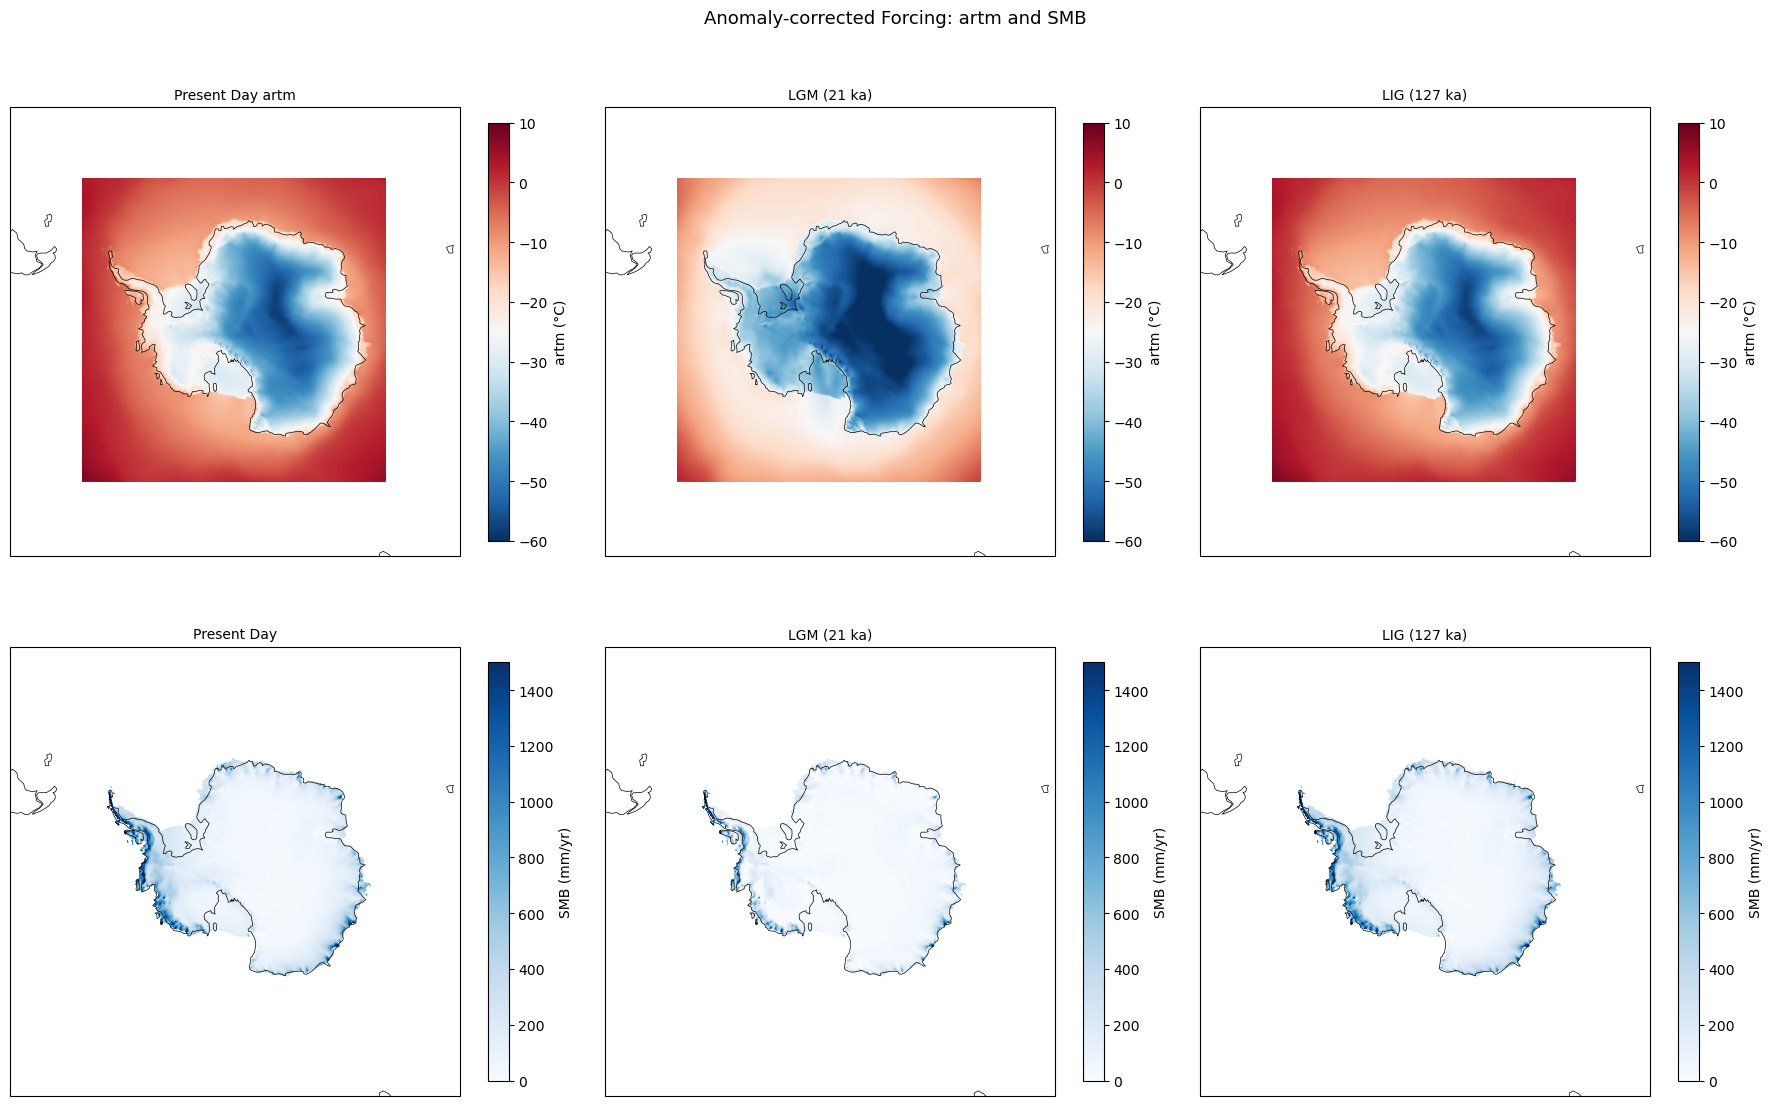

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

ref_artm = np.where(ref["artm"].isel(time=0).values == -99999, np.nan, ref["artm"].isel(time=0).values)
ref_smb  = np.where(np.abs(ref["smb"].isel(time=0).values) > 1e6, np.nan, ref["smb"].isel(time=0).values)

for ax, data, title in zip(axes[0],
                            [ref_artm,
                             lgm_forcing_final["artm"].isel(time=0).values,
                             lig_forcing_final["artm"].isel(time=0).values],
                            ["Present Day", "LGM (21 ka)", "LIG (127 ka)"]):
    p = polar_pcolormesh(ax, lon2d, lat2d, data, "RdBu_r", -60, 10, title)
    plt.colorbar(p, ax=ax, label="artm (°C)", shrink=0.7)

for ax, data, title in zip(axes[1],
                            [ref_smb,
                             lgm_forcing_final["smb"].isel(time=0).values,
                             lig_forcing_final["smb"].isel(time=0).values],
                            ["Present Day", "LGM (21 ka)", "LIG (127 ka)"]):
    p = polar_pcolormesh(ax, lon2d, lat2d, data, "Blues", 0, 1500, title)
    plt.colorbar(p, ax=ax, label="SMB (mm/yr)", shrink=0.7)

axes[0][0].set_title("Present Day artm", fontsize=10)
plt.suptitle("Anomaly-corrected Forcing: artm and SMB", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_anomaly_artm_smb.png", dpi=150)
plt.show()

In [40]:
print("=== REFERENCE ===")
for var in ref.data_vars:
    print(f"{var:<20} dims={ref[var].dims} dtype={ref[var].dtype} units={ref[var].attrs.get('units','?')}")

print("\n=== LGM FORCING ===")
for var in lgm_forcing_final.data_vars:
    print(f"{var:<20} dims={lgm_forcing_final[var].dims} dtype={lgm_forcing_final[var].dtype} units={lgm_forcing_final[var].attrs.get('units','?')}")

print("\n=== LIG FORCING ===")
for var in lig_forcing_final.data_vars:
    print(f"{var:<20} dims={lig_forcing_final[var].dims} dtype={lig_forcing_final[var].dtype} units={lig_forcing_final[var].attrs.get('units','?')}")

print("\n=== COORDINATE COMPARISON ===")
for coord in ["time", "x1", "y1", "zocn"]:
    ref_c   = ref[coord].values if coord in ref.coords else "MISSING"
    lgm_c   = lgm_forcing_final[coord].values if coord in lgm_forcing_final.coords else "MISSING"
    print(f"{coord}:")
    print(f"  ref: dtype={ref[coord].dtype if coord in ref.coords else '?'}, values={ref_c[:3] if coord in ref.coords else '?'}...")
    print(f"  lgm: dtype={lgm_forcing_final[coord].dtype if coord in lgm_forcing_final.coords else '?'}, values={lgm_c[:3] if coord in lgm_forcing_final.coords else '?'}...")

=== REFERENCE ===
firn                 dims=('time', 'y1', 'x1') dtype=float32 units=m
geoid                dims=('time', 'y1', 'x1') dtype=float32 units=m
mask                 dims=('time', 'y1', 'x1') dtype=float32 units=?
thk                  dims=('time', 'y1', 'x1') dtype=float32 units=m
topg                 dims=('time', 'y1', 'x1') dtype=float32 units=m
topg_err             dims=('time', 'y1', 'x1') dtype=float32 units=m
topg75               dims=('time', 'y1', 'x1') dtype=float32 units=m
topgmax              dims=('time', 'y1', 'x1') dtype=float32 units=m
usurf                dims=('time', 'y1', 'x1') dtype=float32 units=m
smb                  dims=('time', 'y1', 'x1') dtype=float32 units=mm/yr water equivalent
artm                 dims=('time', 'y1', 'x1') dtype=float32 units=degree celsius
bheatflx             dims=('time', 'y1', 'x1') dtype=float32 units=W/m2
usfc_obs             dims=('time', 'y0', 'x0') dtype=float32 units=m/yr
vsfc_obs             dims=('time', 'y0', 'x0'

In [41]:
# Start from a copy of the reference
lgm_out = ref.copy(deep=True)
lig_out = ref.copy(deep=True)

# Replace climate forcing variables with paleo values
lgm_out["artm"]            = lgm_forcing_final["artm"]
lgm_out["smb"]             = lgm_forcing_final["smb"]
lgm_out["thermal_forcing"] = lgm_forcing_final["thermal_forcing"]

lig_out["artm"]            = lig_forcing_final["artm"]
lig_out["smb"]             = lig_forcing_final["smb"]
lig_out["thermal_forcing"] = lig_forcing_final["thermal_forcing"]

# Confirm
print("=== LGM OUTPUT ===")
for var in lgm_out.data_vars:
    print(f"{var:<20} dims={lgm_out[var].dims} dtype={lgm_out[var].dtype}")

print("\n=== LIG OUTPUT ===")
for var in lig_out.data_vars:
    print(f"{var:<20} dims={lig_out[var].dims} dtype={lig_out[var].dtype}")

=== LGM OUTPUT ===
firn                 dims=('time', 'y1', 'x1') dtype=float32
geoid                dims=('time', 'y1', 'x1') dtype=float32
mask                 dims=('time', 'y1', 'x1') dtype=float32
thk                  dims=('time', 'y1', 'x1') dtype=float32
topg                 dims=('time', 'y1', 'x1') dtype=float32
topg_err             dims=('time', 'y1', 'x1') dtype=float32
topg75               dims=('time', 'y1', 'x1') dtype=float32
topgmax              dims=('time', 'y1', 'x1') dtype=float32
usurf                dims=('time', 'y1', 'x1') dtype=float32
smb                  dims=('time', 'y1', 'x1') dtype=float32
artm                 dims=('time', 'y1', 'x1') dtype=float32
bheatflx             dims=('time', 'y1', 'x1') dtype=float32
usfc_obs             dims=('time', 'y0', 'x0') dtype=float32
vsfc_obs             dims=('time', 'y0', 'x0') dtype=float32
thermal_forcing      dims=('time', 'zocn', 'y1', 'x1') dtype=float32
ice_domain_mask      dims=('time', 'y1', 'x1') dtype=int32

In [42]:
import os

lgm_out.to_netcdf("CISM3_initialization_AIS_08000.lgm21ka.nc")
lig_out.to_netcdf("CISM3_initialization_AIS_08000.lig127ka.nc")

print("LGM file size:", os.path.getsize("CISM3_initialization_AIS_08000.lgm21ka.nc") / 1e6, "MB")
print("LIG file size:", os.path.getsize("CISM3_initialization_AIS_08000.lig127ka.nc") / 1e6, "MB")
print("Reference file size:", os.path.getsize("/glade/campaign/cesm/development/liwg/forAdvik/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc") / 1e6, "MB")

LGM file size: 118.190389 MB
LIG file size: 118.190389 MB
Reference file size: 118.18513 MB


In [48]:
print(lgm_out)

<xarray.Dataset> Size: 118MB
Dimensions:          (time: 1, x1: 761, y1: 761, x0: 760, y0: 760, zocn: 30)
Coordinates:
  * time             (time) float32 4B 0.0
  * x1               (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * y1               (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * x0               (x0) float32 3kB -3.036e+06 -3.028e+06 ... 3.036e+06
  * y0               (y0) float32 3kB -3.036e+06 -3.028e+06 ... 3.036e+06
  * zocn             (zocn) float32 120B -30.0 -90.0 ... -1.71e+03 -1.77e+03
Data variables: (12/22)
    firn             (time, y1, x1) float32 2MB ...
    geoid            (time, y1, x1) float32 2MB ...
    mask             (time, y1, x1) float32 2MB ...
    thk              (time, y1, x1) float32 2MB ...
    topg             (time, y1, x1) float32 2MB ...
    topg_err         (time, y1, x1) float32 2MB ...
    ...               ...
    dthk_dt_obs      (time, y1, x1) float32 2MB ...
    Lat1             (time, y1, x1) float32 2MB ...
   

In [60]:
print(lgm_out['smb'])

<xarray.DataArray 'smb' (time: 1, y1: 761, x1: 761)> Size: 2MB
dask.array<getitem, shape=(1, 761, 761), dtype=float32, chunksize=(1, 761, 761), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) float32 4B 0.0
  * x1       (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y1       (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
Attributes:
    units:      mm/yr water equivalent
    long_name:  surface mass balance
    note:       RACMO2.3 present-day + iCESM paleo anomaly


In [64]:
restart = xr.open_dataset("/glade/derecho/scratch/advike/lgm_spinup_test/Antarctica_8km.restart.spinup_10kyr.nc", decode_cf=False)

print("=== RESTART FILE VARIABLES ===")
for var in restart.data_vars:
    print(f"{var:<20} dims={restart[var].dims} dtype={restart[var].dtype}")

print("\n=== RESTART COORDS ===")
print(restart.coords)

=== RESTART FILE VARIABLES ===
artm                 dims=('time', 'y1', 'x1') dtype=float64
basin_number         dims=('time', 'y1', 'x1') dtype=int32
beta                 dims=('time', 'y0', 'x0') dtype=float64
bfricflx             dims=('time', 'y1', 'x1') dtype=float64
bheatflx             dims=('time', 'y1', 'x1') dtype=float64
btractx              dims=('time', 'y0', 'x0') dtype=float64
btracty              dims=('time', 'y0', 'x0') dtype=float64
calving_mask         dims=('time', 'y1', 'x1') dtype=int32
coulomb_c            dims=('time', 'y0', 'x0') dtype=float64
deltaT_ocn           dims=('time', 'y1', 'x1') dtype=float64
dissipstag           dims=('time', 'staglevel', 'y1', 'x1') dtype=float64
dthk_dt_obs          dims=('time', 'y1', 'x1') dtype=float64
dthk_dt_obs_basin    dims=('time', 'y1', 'x1') dtype=float64
efvs                 dims=('time', 'staglevel', 'y1', 'x1') dtype=float64
f_effecpress_ocean_p dims=('time', 'y1', 'x1') dtype=float64
ice_domain_mask      dims=('time

In [67]:
lgm_restart = restart.copy(deep=True)

# Replace climate forcing using .values to bypass coordinate alignment
lgm_restart["artm"].values[:] = lgm_forcing_final["artm"].values.astype("float64")
lgm_restart["smb"].values[:]  = lgm_forcing_final["smb"].values.astype("float64")
lgm_restart["thermal_forcing"].values[:] = lgm_forcing_final["thermal_forcing"].values.astype("float64")

# Verify
print("=== artm ===")
print(f"restart original: min={float(restart['artm'].min()):.3f}, max={float(restart['artm'].max()):.3f}")
print(f"lgm restart:      min={float(lgm_restart['artm'].min()):.3f}, max={float(lgm_restart['artm'].max()):.3f}")

print("\n=== smb ===")
print(f"restart original: min={float(restart['smb'].min()):.3f}, max={float(restart['smb'].max()):.3f}")
print(f"lgm restart:      min={float(lgm_restart['smb'].min()):.3f}, max={float(lgm_restart['smb'].max()):.3f}")

print("\n=== thermal_forcing ===")
print(f"restart original: min={float(restart['thermal_forcing'].min()):.3f}, max={float(restart['thermal_forcing'].max()):.3f}")
print(f"lgm restart:      min={float(lgm_restart['thermal_forcing'].min()):.3f}, max={float(lgm_restart['thermal_forcing'].max()):.3f}")

print("\n=== geometry unchanged ===")
print(f"thk:  restart={float(restart['thk'].mean()):.3f}, lgm={float(lgm_restart['thk'].mean()):.3f}")
print(f"topg: restart={float(restart['topg'].mean()):.3f}, lgm={float(lgm_restart['topg'].mean()):.3f}")

=== artm ===
restart original: min=-58.075, max=1.024
lgm restart:      min=-65.315, max=2.122

=== smb ===
restart original: min=-436.124, max=4764.354
lgm restart:      min=-574.835, max=4521.966

=== thermal_forcing ===
restart original: min=-99999.000, max=5.131
lgm restart:      min=-99999.000, max=4.086

=== geometry unchanged ===
thk:  restart=706.753, lgm=706.753
topg: restart=-486.352, lgm=-486.352


In [68]:
lgm_restart.to_netcdf("Antarctica_8km.restart.lgm21ka_initial.nc")

print("Done!")
print("File size:", os.path.getsize("Antarctica_8km.restart.lgm21ka_initial.nc") / 1e6, "MB")
print("Original size:", os.path.getsize("/glade/derecho/scratch/advike/lgm_spinup_test/Antarctica_8km.restart.spinup_10kyr.nc") / 1e6, "MB")

Done!
File size: 1212.275363 MB
Original size: 1180.361036 MB


In [69]:
lig_restart = restart.copy(deep=True)

# Replace climate forcing using .values to bypass coordinate alignment
lig_restart["artm"].values[:] = lig_forcing_final["artm"].values.astype("float64")
lig_restart["smb"].values[:]  = lig_forcing_final["smb"].values.astype("float64")
lig_restart["thermal_forcing"].values[:] = lig_forcing_final["thermal_forcing"].values.astype("float64")

# Verify
print("=== artm ===")
print(f"restart original: min={float(restart['artm'].min()):.3f}, max={float(restart['artm'].max()):.3f}")
print(f"lig restart:      min={float(lig_restart['artm'].min()):.3f}, max={float(lig_restart['artm'].max()):.3f}")

print("\n=== smb ===")
print(f"restart original: min={float(restart['smb'].min()):.3f}, max={float(restart['smb'].max()):.3f}")
print(f"lig restart:      min={float(lig_restart['smb'].min()):.3f}, max={float(lig_restart['smb'].max()):.3f}")

print("\n=== thermal_forcing ===")
print(f"restart original: min={float(restart['thermal_forcing'].min()):.3f}, max={float(restart['thermal_forcing'].max()):.3f}")
print(f"lig restart:      min={float(lig_restart['thermal_forcing'].min()):.3f}, max={float(lig_restart['thermal_forcing'].max()):.3f}")

print("\n=== geometry unchanged ===")
print(f"thk:  restart={float(restart['thk'].mean()):.3f}, lig={float(lig_restart['thk'].mean()):.3f}")
print(f"topg: restart={float(restart['topg'].mean()):.3f}, lig={float(lig_restart['topg'].mean()):.3f}")

# Save
lig_restart.to_netcdf("Antarctica_8km.restart.lig127ka_initial.nc")
print("\nDone!")
print("File size:", os.path.getsize("Antarctica_8km.restart.lig127ka_initial.nc") / 1e6, "MB")

=== artm ===
restart original: min=-58.075, max=1.024
lig restart:      min=-58.173, max=8.064

=== smb ===
restart original: min=-436.124, max=4764.354
lig restart:      min=-415.865, max=4714.793

=== thermal_forcing ===
restart original: min=-99999.000, max=5.131
lig restart:      min=-99999.000, max=9.509

=== geometry unchanged ===
thk:  restart=706.753, lig=706.753
topg: restart=-486.352, lig=-486.352

Done!
File size: 1212.275363 MB


In [70]:
full_restart = xr.open_dataset("/glade/derecho/scratch/advike/lgm_spinup_test/Antarctica_8km.restart.nc", decode_cf=False)

In [71]:
print(full_restart)

<xarray.Dataset> Size: 3GB
Dimensions:               (time: 2, glacierid: 1, level: 41, lithoz: 20,
                           staglevel: 40, stagwbndlevel: 42, x0: 760, x1: 761,
                           y0: 760, y1: 761, zatm: 1, zocn: 30)
Coordinates:
  * time                  (time) float64 16B 1e+03 2e+03
  * glacierid             (glacierid) float64 8B 9.969e+36
  * level                 (level) float64 328B 0.0 0.00191 ... 0.9981 1.0
  * lithoz                (lithoz) float64 160B 9.969e+36 ... 9.969e+36
  * staglevel             (staglevel) float64 320B 0.0009551 0.003131 ... 0.999
  * stagwbndlevel         (stagwbndlevel) float64 336B 0.0 0.0009551 ... 1.0
  * x0                    (x0) float64 6kB -3.036e+06 -3.028e+06 ... 3.036e+06
  * x1                    (x1) float64 6kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * y0                    (y0) float64 6kB -3.036e+06 -3.028e+06 ... 3.036e+06
  * y1                    (y1) float64 6kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * zatm     

In [72]:
restart_full = xr.open_dataset("/glade/derecho/scratch/advike/lgm_spinup_test/Antarctica_8km.restart.nc", decode_cf=False)

# Check what variables need replacing
print("artm shape:", restart_full["artm"].shape)
print("smb shape:", restart_full["smb"].shape)
print("thermal_forcing shape:", restart_full["thermal_forcing"].shape)
print("time values:", restart_full["time"].values)

artm shape: (2, 761, 761)
smb shape: (2, 761, 761)
thermal_forcing shape: (2, 30, 761, 761)
time values: [1000. 2000.]


In [73]:
# LGM
lgm_restart_full = restart_full.copy(deep=True)

lgm_artm_2d = np.repeat(lgm_forcing_final["artm"].values.astype("float64"), 2, axis=0)
lgm_smb_2d  = np.repeat(lgm_forcing_final["smb"].values.astype("float64"), 2, axis=0)
lgm_tf_2d   = np.repeat(lgm_forcing_final["thermal_forcing"].values.astype("float64"), 2, axis=0)

lgm_restart_full["artm"].values[:] = lgm_artm_2d
lgm_restart_full["smb"].values[:]  = lgm_smb_2d
lgm_restart_full["thermal_forcing"].values[:] = lgm_tf_2d

# LIG
lig_restart_full = restart_full.copy(deep=True)

lig_artm_2d = np.repeat(lig_forcing_final["artm"].values.astype("float64"), 2, axis=0)
lig_smb_2d  = np.repeat(lig_forcing_final["smb"].values.astype("float64"), 2, axis=0)
lig_tf_2d   = np.repeat(lig_forcing_final["thermal_forcing"].values.astype("float64"), 2, axis=0)

lig_restart_full["artm"].values[:] = lig_artm_2d
lig_restart_full["smb"].values[:]  = lig_smb_2d
lig_restart_full["thermal_forcing"].values[:] = lig_tf_2d

# Verify
print("=== LGM ===")
print(f"artm: min={float(lgm_restart_full['artm'].min()):.3f}, max={float(lgm_restart_full['artm'].max()):.3f}")
print(f"smb:  min={float(lgm_restart_full['smb'].min()):.3f}, max={float(lgm_restart_full['smb'].max()):.3f}")
print(f"tf:   min={float(lgm_restart_full['thermal_forcing'].min()):.3f}, max={float(lgm_restart_full['thermal_forcing'].max()):.3f}")
print(f"thk unchanged: {float(restart_full['thk'].mean()):.3f} == {float(lgm_restart_full['thk'].mean()):.3f}")

print("\n=== LIG ===")
print(f"artm: min={float(lig_restart_full['artm'].min()):.3f}, max={float(lig_restart_full['artm'].max()):.3f}")
print(f"smb:  min={float(lig_restart_full['smb'].min()):.3f}, max={float(lig_restart_full['smb'].max()):.3f}")
print(f"tf:   min={float(lig_restart_full['thermal_forcing'].min()):.3f}, max={float(lig_restart_full['thermal_forcing'].max()):.3f}")
print(f"thk unchanged: {float(restart_full['thk'].mean()):.3f} == {float(lig_restart_full['thk'].mean()):.3f}")

# Save
lgm_restart_full.to_netcdf("Antarctica_8km.restart.lgm21ka.nc")
lig_restart_full.to_netcdf("Antarctica_8km.restart.lig127ka.nc")

print("\nSaved!")
print("LGM size:", os.path.getsize("Antarctica_8km.restart.lgm21ka.nc") / 1e6, "MB")
print("LIG size:", os.path.getsize("Antarctica_8km.restart.lig127ka.nc") / 1e6, "MB")

=== LGM ===
artm: min=-65.315, max=2.122
smb:  min=-574.835, max=4521.966
tf:   min=-99999.000, max=4.086
thk unchanged: 707.459 == 707.459

=== LIG ===
artm: min=-58.173, max=8.064
smb:  min=-415.865, max=4714.793
tf:   min=-99999.000, max=9.509
thk unchanged: 707.459 == 707.459

Saved!
LGM size: 2795.981205 MB
LIG size: 2795.981205 MB


In [74]:
restart = xr.open_dataset("/glade/derecho/scratch/advike/lgm_spinup_test/Antarctica_8km.restart.spinup_10kyr.nc", decode_cf=False)
print("original TF attrs:", restart["thermal_forcing"].attrs)
print("original TF min:", float(restart["thermal_forcing"].min()))
print("original TF unique non-valid values:", np.unique(restart["thermal_forcing"].values[restart["thermal_forcing"].values < -100]))

original TF attrs: {'units': 'degrees K', 'long_name': 'thermal_forcing', 'read_once': 'False', '_FillValue': np.float64(1e+20), 'missing_value': np.float64(1e+20)}
original TF min: -99999.0
original TF unique non-valid values: [-99999.]


In [75]:
fill_val = 1e+20

for fname, ds in [("Antarctica_8km.restart.lgm21ka_initial.nc", lgm_restart),
                  ("Antarctica_8km.restart.lgm21ka.nc", lgm_restart_full)]:
    ds["thermal_forcing"].values[ds["thermal_forcing"].values == -99999] = fill_val
    print(f"LGM TF min after fix: {float(ds['thermal_forcing'].min()):.3f}")
    print(f"LGM TF max after fix: {float(ds['thermal_forcing'].max()):.3f}")
    ds.to_netcdf(fname)
    print(f"Saved {fname}")

for fname, ds in [("Antarctica_8km.restart.lig127ka_initial.nc", lig_restart),
                  ("Antarctica_8km.restart.lig127ka.nc", lig_restart_full)]:
    ds["thermal_forcing"].values[ds["thermal_forcing"].values == -99999] = fill_val
    print(f"LIG TF min after fix: {float(ds['thermal_forcing'].min()):.3f}")
    print(f"LIG TF max after fix: {float(ds['thermal_forcing'].max()):.3f}")
    ds.to_netcdf(fname)
    print(f"Saved {fname}")

LGM TF min after fix: -1.269
LGM TF max after fix: 100000000000000000000.000
Saved Antarctica_8km.restart.lgm21ka_initial.nc
LGM TF min after fix: -1.269
LGM TF max after fix: 100000000000000000000.000
Saved Antarctica_8km.restart.lgm21ka.nc
LIG TF min after fix: -1.236
LIG TF max after fix: 100000000000000000000.000
Saved Antarctica_8km.restart.lig127ka_initial.nc
LIG TF min after fix: -1.236
LIG TF max after fix: 100000000000000000000.000
Saved Antarctica_8km.restart.lig127ka.nc


In [81]:
# Fix smb NaNs
lgm_smb_fixed = lgm_restart["smb"].values.copy()
lgm_smb_fixed = np.where(np.isnan(lgm_smb_fixed), 0.0, lgm_smb_fixed)

lig_smb_fixed = lig_restart["smb"].values.copy()
lig_smb_fixed = np.where(np.isnan(lig_smb_fixed), 0.0, lig_smb_fixed)

# Fix thermal_forcing — revert to -99999
lgm_tf_fixed = lgm_restart["thermal_forcing"].values.copy()
lgm_tf_fixed = np.where(lgm_tf_fixed >= 1e19, -99999.0, lgm_tf_fixed)

lig_tf_fixed = lig_restart["thermal_forcing"].values.copy()
lig_tf_fixed = np.where(lig_tf_fixed >= 1e19, -99999.0, lig_tf_fixed)

# Apply and save to new filenames
lgm_restart["smb"].values[:] = lgm_smb_fixed
lgm_restart["thermal_forcing"].values[:] = lgm_tf_fixed
lgm_restart.to_netcdf("Antarctica_8km.restart.lgm21ka_initial.fixed.nc")
print("Saved LGM initial")

lgm_restart_full["smb"].values[:] = np.repeat(lgm_smb_fixed, 2, axis=0)
lgm_restart_full["thermal_forcing"].values[:] = np.repeat(lgm_tf_fixed, 2, axis=0)
lgm_restart_full.to_netcdf("Antarctica_8km.restart.lgm21ka.fixed.nc")
print("Saved LGM full")

lig_restart["smb"].values[:] = lig_smb_fixed
lig_restart["thermal_forcing"].values[:] = lig_tf_fixed
lig_restart.to_netcdf("Antarctica_8km.restart.lig127ka_initial.fixed.nc")
print("Saved LIG initial")

lig_restart_full["smb"].values[:] = np.repeat(lig_smb_fixed, 2, axis=0)
lig_restart_full["thermal_forcing"].values[:] = np.repeat(lig_tf_fixed, 2, axis=0)
lig_restart_full.to_netcdf("Antarctica_8km.restart.lig127ka.fixed.nc")
print("Saved LIG full")

Saved LGM initial


ValueError: could not broadcast input array from shape (2,761,761) into shape (0,761,761)

In [84]:
# Rebuild lgm_restart_full from the original
restart_full = xr.open_dataset("/glade/derecho/scratch/advike/lgm_spinup_test/Antarctica_8km.restart.nc", decode_cf=False).load()

lgm_restart_full = restart_full.copy(deep=True)
lgm_restart_full["artm"].values[:] = np.repeat(lgm_forcing_final["artm"].values.astype("float64"), 2, axis=0)
lgm_restart_full["smb"].values[:] = np.repeat(lgm_smb_fixed, 2, axis=0)
lgm_restart_full["thermal_forcing"].values[:] = np.repeat(lgm_tf_fixed, 2, axis=0)

print("lgm_restart_full smb shape:", lgm_restart_full["smb"].shape)
print("smb NaN count:", np.isnan(lgm_restart_full["smb"].values).sum())
print("smb min:", float(lgm_restart_full["smb"].min()))
print("smb max:", float(lgm_restart_full["smb"].max()))
print("tf min:", float(lgm_restart_full["thermal_forcing"].min()))
print("tf max:", float(lgm_restart_full["thermal_forcing"].max()))
print("thk unchanged:", float(restart_full["thk"].mean()), "==", float(lgm_restart_full["thk"].mean()))

lgm_restart_full smb shape: (2, 761, 761)
smb NaN count: 0
smb min: -574.83544921875
smb max: 4521.96630859375
tf min: -99999.0
tf max: 4.086397647857666
thk unchanged: 707.4590449620827 == 707.4590449620827


In [85]:
lgm_restart_full.to_netcdf("Antarctica_8km.restart.lgm21ka.fixed.nc")
print("Saved LGM full")

lig_restart_full["smb"].values[:] = np.repeat(lig_smb_fixed, 2, axis=0)
lig_restart_full["thermal_forcing"].values[:] = np.repeat(lig_tf_fixed, 2, axis=0)
lig_restart_full.to_netcdf("Antarctica_8km.restart.lig127ka.fixed.nc")
print("Saved LIG full")

lgm_restart.to_netcdf("Antarctica_8km.restart.lgm21ka_initial.fixed.nc")
print("Saved LGM initial")

lig_restart.to_netcdf("Antarctica_8km.restart.lig127ka_initial.fixed.nc")
print("Saved LIG initial")

Saved LGM full
Saved LIG full
Saved LGM initial
Saved LIG initial


In [86]:
restart_full = xr.open_dataset("/glade/derecho/scratch/advike/lgm_spinup_test/Antarctica_8km.restart.nc", decode_cf=False).load()

lgm_restart_full = restart_full.copy(deep=True)
lgm_restart_full["artm"].values[:] = np.repeat(lgm_forcing_final["artm"].values.astype("float64"), 2, axis=0)
lgm_restart_full["smb"].values[:] = np.repeat(lgm_smb_fixed, 2, axis=0)
lgm_restart_full["thermal_forcing"].values[:] = np.repeat(lgm_tf_fixed, 2, axis=0)

print("smb shape:", lgm_restart_full["smb"].shape)
print("smb NaN count:", np.isnan(lgm_restart_full["smb"].values).sum())
print("tf min:", float(lgm_restart_full["thermal_forcing"].min()))
print("tf max:", float(lgm_restart_full["thermal_forcing"].max()))
print("thk unchanged:", float(restart_full["thk"].mean()), "==", float(lgm_restart_full["thk"].mean()))

lgm_restart_full.to_netcdf("Antarctica_8km.restart.lgm21ka.fixed.nc")
print("Saved — size should be ~2.8GB")

smb shape: (2, 761, 761)
smb NaN count: 0
tf min: -99999.0
tf max: 4.086397647857666
thk unchanged: 707.4590449620827 == 707.4590449620827
Saved — size should be ~2.8GB


In [88]:
# Load present-day TF from original restart as fallback
restart_orig = xr.open_dataset("/glade/derecho/scratch/advike/lgm_spinup_test/Antarctica_8km.restart.spinup_10kyr.nc", decode_cf=False).load()

ref_tf = restart_orig["thermal_forcing"].values  # shape (1, 30, 761, 761)
lgm_tf = lgm_restart["thermal_forcing"].values   # shape (1, 30, 761, 761)

# Where LGM TF is -99999, use present-day TF instead
lgm_tf_filled = np.where(lgm_tf == -99999, ref_tf, lgm_tf)

print("Before fill - -99999 count:", (lgm_tf == -99999).sum())
print("After fill - -99999 count:", (lgm_tf_filled == -99999).sum())
print("After fill - min:", lgm_tf_filled.min())
print("After fill - max:", lgm_tf_filled.max())

Before fill - -99999 count: 7929845
After fill - -99999 count: 60
After fill - min: -99999.0
After fill - max: 5.13145112991333


In [89]:
lgm_tf_filled = np.where(lgm_tf_filled == -99999, 0.0, lgm_tf_filled)

print("Final -99999 count:", (lgm_tf_filled == -99999).sum())
print("Final min:", lgm_tf_filled.min())
print("Final max:", lgm_tf_filled.max())

# Do the same for LIG
lig_tf = lig_restart["thermal_forcing"].values
lig_tf_filled = np.where(lig_tf == -99999, ref_tf, lig_tf)
lig_tf_filled = np.where(lig_tf_filled == -99999, 0.0, lig_tf_filled)

print("\nLIG final -99999 count:", (lig_tf_filled == -99999).sum())
print("LIG final min:", lig_tf_filled.min())
print("LIG final max:", lig_tf_filled.max())

Final -99999 count: 0
Final min: -1.2685433626174927
Final max: 5.13145112991333

LIG final -99999 count: 0
LIG final min: -1.2358249425888062
LIG final max: 1e+20


In [90]:
lig_tf_filled = np.where(lig_tf_filled >= 1e19, ref_tf, lig_tf_filled)
lig_tf_filled = np.where(lig_tf_filled >= 1e19, 0.0, lig_tf_filled)

print("LIG final -99999 count:", (lig_tf_filled == -99999).sum())
print("LIG final 1e20 count:", (lig_tf_filled >= 1e19).sum())
print("LIG final min:", lig_tf_filled.min())
print("LIG final max:", lig_tf_filled.max())

LIG final -99999 count: 15
LIG final 1e20 count: 0
LIG final min: -99999.0
LIG final max: 9.508837699890137


In [91]:
lig_tf_filled = np.where(lig_tf_filled == -99999, 0.0, lig_tf_filled)

print("LIG final -99999 count:", (lig_tf_filled == -99999).sum())
print("LIG final 1e20 count:", (lig_tf_filled >= 1e19).sum())
print("LIG final min:", lig_tf_filled.min())
print("LIG final max:", lig_tf_filled.max())

LIG final -99999 count: 0
LIG final 1e20 count: 0
LIG final min: -1.2358249425888062
LIG final max: 9.508837699890137


In [92]:
# Apply to single timestep restart files
lgm_restart["thermal_forcing"].values[:] = lgm_tf_filled
lig_restart["thermal_forcing"].values[:] = lig_tf_filled

lgm_restart.to_netcdf("Antarctica_8km.restart.lgm21ka_initial.fixed.nc")
print("Saved LGM initial")

lig_restart.to_netcdf("Antarctica_8km.restart.lig127ka_initial.fixed.nc")
print("Saved LIG initial")

# Apply to two-timestep restart files
lgm_restart_full["thermal_forcing"].values[:] = np.repeat(lgm_tf_filled, 2, axis=0)
lig_restart_full["thermal_forcing"].values[:] = np.repeat(lig_tf_filled, 2, axis=0)

lgm_restart_full.to_netcdf("Antarctica_8km.restart.lgm21ka.fixed.nc")
print("Saved LGM full")

lig_restart_full.to_netcdf("Antarctica_8km.restart.lig127ka.fixed.nc")
print("Saved LIG full")

Saved LGM initial
Saved LIG initial
Saved LGM full
Saved LIG full


In [97]:
ref_pd = xr.open_dataset("/glade/campaign/cesm/development/liwg/forAdvik/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc", decode_cf=False)
lgm_result = xr.open_dataset("/glade/derecho/scratch/advike/lgm_spinup_test/out_Antarctica_8km.nc", decode_cf=False)

lon2d = ref_pd["Lon1"].isel(time=0).values
lat2d = ref_pd["Lat1"].isel(time=0).values

lgm_tf_orig = xr.open_dataset("/glade/u/home/advike/CESM_Regrid/lgm21ka_ocn_thermal_forcing_on_cism8km.nc", decode_cf=False)
tf_val = lgm_tf_orig["thermal_forcing"].isel(time=0, zocn=0).values
invalid = (tf_val == -99999)

# Now continue
ref_tf_full = ref_pd["thermal_forcing"].isel(time=0).values.copy()
ref_tf_full = np.where(ref_tf_full == -99999, np.nan, ref_tf_full)

lgm_tf_icesm = lgm_tf_orig["thermal_forcing"].isel(time=0).values.copy()
lgm_tf_icesm = np.where(lgm_tf_icesm == -99999, np.nan, lgm_tf_icesm)

n_zocn = lgm_tf_icesm.shape[0]
anomaly_per_level = np.zeros(n_zocn)

for k in range(n_zocn):
    lgm_valid = lgm_tf_icesm[k][~np.isnan(lgm_tf_icesm[k])]
    ref_valid = ref_tf_full[k][~np.isnan(ref_tf_full[k])]
    lgm_mean = lgm_valid.mean() if len(lgm_valid) > 0 else 0.0
    ref_mean = ref_valid.mean() if len(ref_valid) > 0 else 0.0
    anomaly_per_level[k] = lgm_mean - ref_mean
    print(f"  zocn level {k}: LGM mean={lgm_mean:.3f}, PD mean={ref_mean:.3f}, anomaly={anomaly_per_level[k]:.3f}")

lgm_restart = xr.open_dataset("/glade/u/home/advike/Antarctica_8km.restart.lgm21ka_initial.fixed.nc", decode_cf=False)

ref_tf = ref_pd["thermal_forcing"].isel(time=0, zocn=0).values
ref_tf_valid = np.where(ref_tf == -99999, np.nan, ref_tf)

lgm_tf_filled_vals = lgm_restart["thermal_forcing"].isel(time=0, zocn=0).values
originally_missing = invalid

print("Values we filled in from PD TF where LGM was missing:")
filled_vals = lgm_tf_filled_vals[originally_missing]
print(f"  min: {filled_vals.min():.3f}")
print(f"  max: {filled_vals.max():.3f}")
print(f"  mean: {filled_vals.mean():.3f}")
print(f"  values > 0 count: {(filled_vals > 0).sum()}")

# Load present-day observational TF (the reference file)
ref_tf_full = ref_pd["thermal_forcing"].isel(time=0).values.copy()  # shape (30, 761, 761)
ref_tf_full = np.where(ref_tf_full == -99999, np.nan, ref_tf_full)

# Load original LGM iCESM TF
lgm_tf_icesm = lgm_tf_orig["thermal_forcing"].isel(time=0).values.copy()  # shape (30, 761, 761)
lgm_tf_icesm = np.where(lgm_tf_icesm == -99999, np.nan, lgm_tf_icesm)

# Compute mean anomaly per depth level using only valid iCESM cells
n_zocn = lgm_tf_icesm.shape[0]
anomaly_per_level = np.zeros(n_zocn)

for k in range(n_zocn):
    lgm_valid = lgm_tf_icesm[k][~np.isnan(lgm_tf_icesm[k])]
    ref_valid = ref_tf_full[k][~np.isnan(ref_tf_full[k])]
    
    # Mean of valid cells for each
    lgm_mean = lgm_valid.mean() if len(lgm_valid) > 0 else 0.0
    ref_mean = ref_valid.mean() if len(ref_valid) > 0 else 0.0
    
    anomaly_per_level[k] = lgm_mean - ref_mean
    print(f"  zocn level {k}: LGM mean={lgm_mean:.3f}, PD mean={ref_mean:.3f}, anomaly={anomaly_per_level[k]:.3f}")

  zocn level 0: LGM mean=0.304, PD mean=0.746, anomaly=-0.442
  zocn level 1: LGM mean=0.244, PD mean=0.737, anomaly=-0.493
  zocn level 2: LGM mean=0.365, PD mean=1.299, anomaly=-0.935
  zocn level 3: LGM mean=0.402, PD mean=1.714, anomaly=-1.312
  zocn level 4: LGM mean=0.382, PD mean=1.911, anomaly=-1.529
  zocn level 5: LGM mean=0.351, PD mean=2.022, anomaly=-1.671
  zocn level 6: LGM mean=0.311, PD mean=2.104, anomaly=-1.793
  zocn level 7: LGM mean=0.270, PD mean=2.171, anomaly=-1.901
  zocn level 8: LGM mean=0.220, PD mean=2.219, anomaly=-1.999
  zocn level 9: LGM mean=0.171, PD mean=2.262, anomaly=-2.091
  zocn level 10: LGM mean=0.120, PD mean=2.302, anomaly=-2.182
  zocn level 11: LGM mean=0.068, PD mean=2.335, anomaly=-2.267
  zocn level 12: LGM mean=0.013, PD mean=2.367, anomaly=-2.354
  zocn level 13: LGM mean=-0.041, PD mean=2.395, anomaly=-2.436
  zocn level 14: LGM mean=-0.097, PD mean=2.422, anomaly=-2.519
  zocn level 15: LGM mean=-0.153, PD mean=2.449, anomaly=-2.602

In [98]:
# Build corrected LGM TF: PD_obs + depth-varying anomaly
lgm_tf_corrected_v2 = np.zeros_like(ref_tf_full)  # shape (30, 761, 761)

for k in range(n_zocn):
    # Start with present-day observational TF
    pd_level = ref_tf_full[k].copy()
    
    # Where iCESM has valid LGM data, use it directly
    lgm_level = lgm_tf_icesm[k].copy()
    valid_mask = ~np.isnan(lgm_level)
    
    # Where iCESM is missing, use PD + anomaly
    filled = np.where(np.isnan(pd_level), anomaly_per_level[k],  # if PD is also NaN use just anomaly
                      pd_level + anomaly_per_level[k])
    
    # Combine: use iCESM where valid, filled elsewhere
    lgm_tf_corrected_v2[k] = np.where(valid_mask, lgm_level, filled)

# Verify
print("Corrected LGM TF stats:")
for k in [0, 14, 29]:
    print(f"  zocn level {k}: min={lgm_tf_corrected_v2[k].min():.3f}, max={lgm_tf_corrected_v2[k].max():.3f}, mean={lgm_tf_corrected_v2[k].mean():.3f}")

print(f"\nAny NaN: {np.isnan(lgm_tf_corrected_v2).sum()}")
print(f"Any -99999: {(lgm_tf_corrected_v2 == -99999).sum()}")
print(f"Overall min: {lgm_tf_corrected_v2.min():.3f}")
print(f"Overall max: {lgm_tf_corrected_v2.max():.3f}")

Corrected LGM TF stats:
  zocn level 0: min=-0.442, max=4.386, mean=0.144
  zocn level 14: min=-2.519, max=1.882, mean=-0.653
  zocn level 29: min=-3.847, max=1.284, mean=-1.390

Any NaN: 0
Any -99999: 0
Overall min: -3.847
Overall max: 4.386


In [99]:
lgm_restart = xr.open_dataset("/glade/u/home/advike/Antarctica_8km.restart.lgm21ka_initial.fixed.nc", decode_cf=False).load()
lgm_restart_full = xr.open_dataset("/glade/u/home/advike/Antarctica_8km.restart.lgm21ka.fixed.nc", decode_cf=False).load()

lgm_restart["thermal_forcing"].values[0] = lgm_tf_corrected_v2
lgm_restart_full["thermal_forcing"].values[0] = lgm_tf_corrected_v2
lgm_restart_full["thermal_forcing"].values[1] = lgm_tf_corrected_v2

print("LGM restart TF min:", float(lgm_restart["thermal_forcing"].min()))
print("LGM restart TF max:", float(lgm_restart["thermal_forcing"].max()))
print("LGM restart full TF min:", float(lgm_restart_full["thermal_forcing"].min()))
print("LGM restart full TF max:", float(lgm_restart_full["thermal_forcing"].max()))

lgm_restart.to_netcdf("Antarctica_8km.restart.lgm21ka_initial.fixed3.nc")
print("Saved initial")
lgm_restart_full.to_netcdf("Antarctica_8km.restart.lgm21ka.fixed3.nc")
print("Saved full")

LGM restart TF min: -3.8470242023468018
LGM restart TF max: 4.385950088500977
LGM restart full TF min: -3.8470242023468018
LGM restart full TF max: 4.385950088500977
Saved initial
Saved full


In [101]:
lig_tf_orig = xr.open_dataset("/glade/u/home/advike/CESM_Regrid/lig127ka_ocn_thermal_forcing_on_cism8km.nc", decode_cf=False)
lig_tf_icesm = lig_tf_orig["thermal_forcing"].isel(time=0).values.copy()
lig_tf_icesm = np.where(lig_tf_icesm == -99999, np.nan, lig_tf_icesm)

lig_anomaly_per_level = np.zeros(n_zocn)

for k in range(n_zocn):
    lig_valid = lig_tf_icesm[k][~np.isnan(lig_tf_icesm[k])]
    ref_valid = ref_tf_full[k][~np.isnan(ref_tf_full[k])]
    lig_mean = lig_valid.mean() if len(lig_valid) > 0 else 0.0
    ref_mean = ref_valid.mean() if len(ref_valid) > 0 else 0.0
    lig_anomaly_per_level[k] = lig_mean - ref_mean
    print(f"  zocn level {k}: LIG mean={lig_mean:.3f}, PD mean={ref_mean:.3f}, anomaly={lig_anomaly_per_level[k]:.3f}")

  zocn level 0: LIG mean=2.300, PD mean=0.746, anomaly=1.554
  zocn level 1: LIG mean=1.708, PD mean=0.737, anomaly=0.971
  zocn level 2: LIG mean=3.070, PD mean=1.299, anomaly=1.771
  zocn level 3: LIG mean=3.599, PD mean=1.714, anomaly=1.886
  zocn level 4: LIG mean=3.710, PD mean=1.911, anomaly=1.799
  zocn level 5: LIG mean=3.723, PD mean=2.022, anomaly=1.701
  zocn level 6: LIG mean=3.710, PD mean=2.104, anomaly=1.606
  zocn level 7: LIG mean=3.712, PD mean=2.171, anomaly=1.541
  zocn level 8: LIG mean=3.680, PD mean=2.219, anomaly=1.461
  zocn level 9: LIG mean=3.638, PD mean=2.262, anomaly=1.376
  zocn level 10: LIG mean=3.602, PD mean=2.302, anomaly=1.300
  zocn level 11: LIG mean=3.553, PD mean=2.335, anomaly=1.218
  zocn level 12: LIG mean=3.498, PD mean=2.367, anomaly=1.132
  zocn level 13: LIG mean=3.446, PD mean=2.395, anomaly=1.051
  zocn level 14: LIG mean=3.385, PD mean=2.422, anomaly=0.963
  zocn level 15: LIG mean=3.326, PD mean=2.449, anomaly=0.877
  zocn level 16: L

In [102]:
# Build corrected LIG TF
lig_tf_corrected = np.zeros_like(ref_tf_full)

for k in range(n_zocn):
    pd_level = ref_tf_full[k].copy()
    lig_level = lig_tf_icesm[k].copy()
    valid_mask = ~np.isnan(lig_level)
    filled = np.where(np.isnan(pd_level), lig_anomaly_per_level[k],
                      pd_level + lig_anomaly_per_level[k])
    lig_tf_corrected[k] = np.where(valid_mask, lig_level, filled)

print("Corrected LIG TF stats:")
for k in [0, 14, 29]:
    print(f"  zocn level {k}: min={lig_tf_corrected[k].min():.3f}, max={lig_tf_corrected[k].max():.3f}, mean={lig_tf_corrected[k].mean():.3f}")
print(f"\nAny NaN: {np.isnan(lig_tf_corrected).sum()}")
print(f"Any -99999: {(lig_tf_corrected == -99999).sum()}")
print(f"Overall min: {lig_tf_corrected.min():.3f}")
print(f"Overall max: {lig_tf_corrected.max():.3f}")

# Rebuild LIG restart files
lig_restart = xr.open_dataset("/glade/u/home/advike/Antarctica_8km.restart.lig127ka_initial.fixed.nc", decode_cf=False).load()
lig_restart_full = xr.open_dataset("/glade/u/home/advike/Antarctica_8km.restart.lig127ka.fixed.nc", decode_cf=False).load()

lig_restart["thermal_forcing"].values[0] = lig_tf_corrected
lig_restart_full["thermal_forcing"].values[0] = lig_tf_corrected
lig_restart_full["thermal_forcing"].values[1] = lig_tf_corrected

print("\nLIG restart TF min:", float(lig_restart["thermal_forcing"].min()))
print("LIG restart TF max:", float(lig_restart["thermal_forcing"].max()))

lig_restart.to_netcdf("Antarctica_8km.restart.lig127ka_initial.fixed3.nc")
print("Saved LIG initial")
lig_restart_full.to_netcdf("Antarctica_8km.restart.lig127ka.fixed3.nc")
print("Saved LIG full")

Corrected LIG TF stats:
  zocn level 0: min=0.051, max=9.999, mean=2.145
  zocn level 14: min=0.963, max=5.364, mean=2.826
  zocn level 29: min=-0.474, max=4.657, mean=1.981

Any NaN: 0
Any -99999: 0
Overall min: -1.164
Overall max: 9.999

LIG restart TF min: -1.164162278175354
LIG restart TF max: 9.998730659484863
Saved LIG initial
Saved LIG full
